# 103 --- Building an Option Chain

This notebook shows how to construct a complete option chain for SPY
from scratch:

1. List expirations and pick the nearest monthly
2. Fetch all strikes
3. Pull snapshot quotes for calls and puts
4. Assemble a unified option chain DataFrame
5. Compute and plot the implied volatility smile
6. Visualize open interest across strikes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from thetadatadx import (
    Credentials, Config, ThetaDataDx, to_dataframe,
    all_greeks, implied_volatility,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

In [2]:
creds = Credentials.from_file("creds.txt")
tdx = ThetaDataDx(creds, Config.production())

## 1. List All Expirations for SPY

In [3]:
expirations = tdx.option_list_expirations("SPY")
print(f"Total expirations: {len(expirations)}")
print(f"First 10: {expirations[:10]}")

Total expirations: 2025
First 10: ['2012-06-01', '2012-06-08', '2012-06-16', '2012-06-22', '2012-06-29', '2012-07-06', '2012-07-13', '2012-07-21', '2012-07-27', '2012-08-03']


## 2. Pick the Nearest Monthly Expiration

SPY has daily (0DTE), weekly, and monthly expirations.
Monthly expirations fall on the third Friday of each month.
We pick the first expiration that is on a Friday and at least 14 days out.

In [4]:
today = datetime.now()

monthly_exp = None
for exp_str in expirations:
    exp_date = datetime.strptime(exp_str.replace("-", ""), "%Y%m%d")
    days_out = (exp_date - today).days
    # Monthly expirations are on Fridays, at least 14 days out
    if days_out >= 14 and exp_date.weekday() == 4:  # Friday
        # Third Friday heuristic: day is between 15th and 21st
        if 15 <= exp_date.day <= 21:
            monthly_exp = exp_str
            break

# Fallback: just use the first expiration >= 20 days out
if monthly_exp is None:
    for exp_str in expirations:
        exp_date = datetime.strptime(exp_str.replace("-", ""), "%Y%m%d")
        if (exp_date - today).days >= 20:
            monthly_exp = exp_str
            break

exp_dt = datetime.strptime(monthly_exp.replace("-", ""), "%Y%m%d")
dte = (exp_dt - today).days
print(f"Selected expiration: {monthly_exp} ({dte} DTE)")

Selected expiration: 2026-05-15 (28 DTE)


## 3. Fetch All Strikes for That Expiration

In [5]:
all_strikes = tdx.option_list_strikes("SPY", monthly_exp)
print(f"Total strikes: {len(all_strikes)}")
print(f"Range: {all_strikes[0]} -- {all_strikes[-1]}")

# Get current spot price from stock snapshot
spot_snap = tdx.stock_snapshot_ohlc(["SPY"])
spot_price = spot_snap["close"][0]
print(f"\nSPY spot: ${spot_price:.2f}")

# Filter to strikes within +/- 10% of spot
strike_values = [float(s) for s in all_strikes]  # Strikes are in dollar units
mask = [(spot_price * 0.90) <= sv <= (spot_price * 1.10) for sv in strike_values]
filtered_strikes = [s for s, m in zip(all_strikes, mask) if m]
print(f"Strikes within +/-10%: {len(filtered_strikes)}")

Total strikes: 221
Range: 661 -- 790



SPY spot: $701.54
Strikes within +/-10%: 95


## 4. Fetch Snapshot Quotes for Calls and Puts

For each strike, we fetch the current NBBO quote for the call
and the put, then assemble the chain.

In [6]:
chain_rows = []

for strike_str in filtered_strikes:
    strike_val = float(strike_str)

    # Fetch call and put quotes
    try:
        call_q = tdx.option_snapshot_quote("SPY", monthly_exp, strike_str, "C")
        put_q = tdx.option_snapshot_quote("SPY", monthly_exp, strike_str, "P")
    except Exception as e:
        continue

    row = {"strike": strike_val}

    if call_q:
        row["call_bid"] = call_q["bid"][0]
        row["call_ask"] = call_q["ask"][0]
        row["call_mid"] = (call_q["bid"][0] + call_q["ask"][0]) / 2
    else:
        row["call_bid"] = row["call_ask"] = row["call_mid"] = np.nan

    if put_q:
        row["put_bid"] = put_q["bid"][0]
        row["put_ask"] = put_q["ask"][0]
        row["put_mid"] = (put_q["bid"][0] + put_q["ask"][0]) / 2
    else:
        row["put_bid"] = row["put_ask"] = row["put_mid"] = np.nan

    chain_rows.append(row)

chain = pd.DataFrame(chain_rows)
print(f"Option chain: {len(chain)} strikes")
chain.head(10)

Option chain: 95 strikes


,strike,call_bid,call_ask,call_mid,put_bid,put_ask,put_mid
0,661.0,43.49,47.31,45.400,2.87,2.89,2.880
1,725.0,2.83,2.84,2.835,23.20,26.74,24.970
2,640.0,64.94,65.18,65.060,1.57,1.59,1.580
3,704.0,11.29,11.33,11.310,11.81,11.86,11.835
4,639.0,64.10,67.89,65.995,1.53,1.55,1.540
5,703.0,11.88,11.93,11.905,11.39,11.44,11.415
6,682.0,25.54,27.66,26.600,5.55,5.59,5.570
7,681.0,26.06,29.60,27.830,5.37,5.41,5.390
8,745.0,0.51,0.53,0.520,41.79,45.41,43.600
9,660.0,46.21,46.44,46.325,2.78,2.79,2.785


## 5. Build the Complete Option Chain DataFrame

In [7]:
# Display a formatted option chain centered around ATM
display_cols = ["call_bid", "call_ask", "call_mid", "strike", "put_bid", "put_ask", "put_mid"]
chain_display = chain[display_cols].copy()

# Highlight ATM strike
atm_idx = (chain["strike"] - spot_price).abs().idxmin()
atm_strike = chain.loc[atm_idx, "strike"]
print(f"ATM strike: ${atm_strike:.0f}  (spot: ${spot_price:.2f})\n")

# Show 10 strikes around ATM
start = max(0, atm_idx - 5)
end = min(len(chain), atm_idx + 6)
chain_display.iloc[start:end]

ATM strike: $702  (spot: $701.54)



,call_bid,call_ask,call_mid,strike,put_bid,put_ask,put_mid
7,26.06,29.60,27.830,681.0,5.37,5.41,5.390
8,0.51,0.53,0.520,745.0,41.79,45.41,43.600
9,46.21,46.44,46.325,660.0,2.78,2.79,2.785
10,45.32,48.78,47.050,659.0,2.70,2.73,2.715
11,65.06,67.77,66.415,638.0,1.49,1.51,1.500
12,12.49,12.53,12.510,702.0,10.98,11.03,11.005
13,66.11,69.79,67.950,637.0,1.45,1.47,1.460
14,13.11,13.15,13.130,701.0,10.61,10.65,10.630
15,0.13,0.14,0.135,765.0,61.79,65.42,63.605
16,28.67,28.90,28.785,680.0,5.20,5.24,5.220


## 6. Implied Volatility Smile

Use the built-in Greeks calculator to compute IV for each strike.

In [8]:
risk_free_rate = 0.05   # approximate
div_yield = 0.013       # SPY dividend yield
tte = dte / 365.0

call_ivs = []
put_ivs = []

for _, row in chain.iterrows():
    strike = row["strike"]

    # Call IV from mid price
    if pd.notna(row["call_mid"]) and row["call_mid"] > 0.01:
        try:
            iv, err = implied_volatility(
                spot_price, strike, risk_free_rate, div_yield, tte,
                row["call_mid"], True
            )
            call_ivs.append(iv if err < 0.01 else np.nan)
        except Exception:
            call_ivs.append(np.nan)
    else:
        call_ivs.append(np.nan)

    # Put IV from mid price
    if pd.notna(row["put_mid"]) and row["put_mid"] > 0.01:
        try:
            iv, err = implied_volatility(
                spot_price, strike, risk_free_rate, div_yield, tte,
                row["put_mid"], False
            )
            put_ivs.append(iv if err < 0.01 else np.nan)
        except Exception:
            put_ivs.append(np.nan)
    else:
        put_ivs.append(np.nan)

chain["call_iv"] = call_ivs
chain["put_iv"] = put_ivs

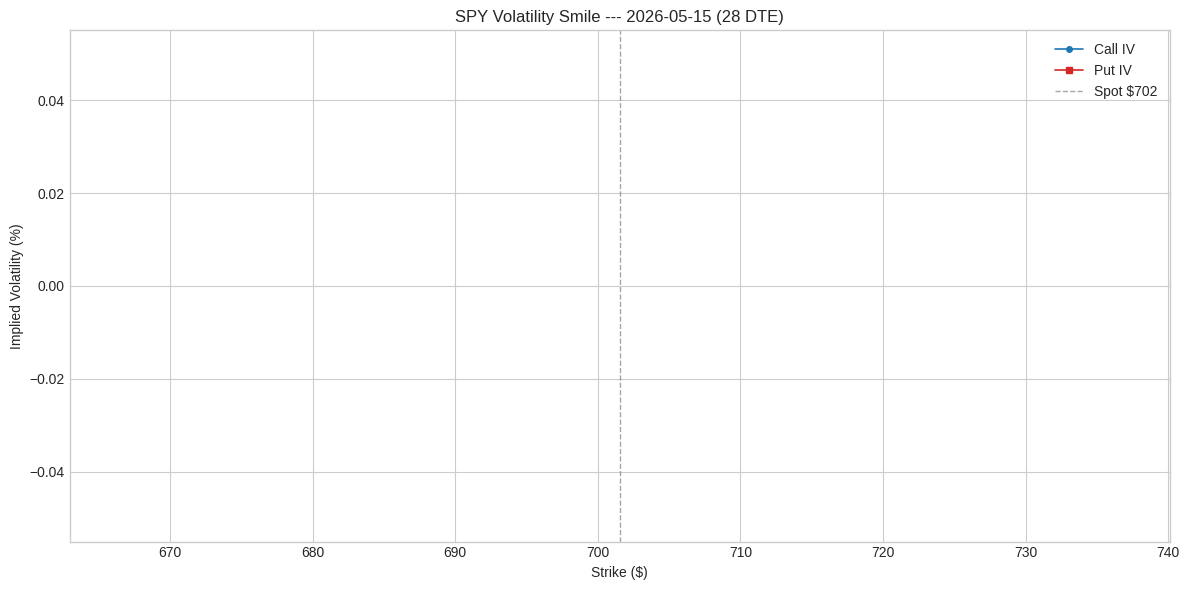

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

valid_call = chain.dropna(subset=["call_iv"])
valid_put = chain.dropna(subset=["put_iv"])

ax.plot(valid_call["strike"], valid_call["call_iv"] * 100, "o-",
        color="#1f77b4", markersize=4, linewidth=1.2, label="Call IV")
ax.plot(valid_put["strike"], valid_put["put_iv"] * 100, "s-",
        color="#d62728", markersize=4, linewidth=1.2, label="Put IV")

ax.axvline(x=spot_price, color="gray", linestyle="--", linewidth=1, alpha=0.7,
           label=f"Spot ${spot_price:.0f}")

ax.set_xlabel("Strike ($)")
ax.set_ylabel("Implied Volatility (%)")
ax.set_title(f"SPY Volatility Smile --- {monthly_exp} ({dte} DTE)")
ax.legend()

plt.tight_layout()
plt.show()

## 7. Open Interest Across Strikes

In [10]:
call_oi_list = []
put_oi_list = []

for strike_str in filtered_strikes:
    strike_val = float(strike_str)

    try:
        call_oi = tdx.option_snapshot_open_interest("SPY", monthly_exp, strike_str, "C")
        put_oi = tdx.option_snapshot_open_interest("SPY", monthly_exp, strike_str, "P")
    except Exception:
        call_oi_list.append(0)
        put_oi_list.append(0)
        continue

    # open_interest returns a DataTable; extract the OI value
    c_val = call_oi.get("open_interest", [0])[0] if call_oi else 0
    p_val = put_oi.get("open_interest", [0])[0] if put_oi else 0
    call_oi_list.append(c_val if isinstance(c_val, (int, float)) else 0)
    put_oi_list.append(p_val if isinstance(p_val, (int, float)) else 0)

chain["call_oi"] = call_oi_list
chain["put_oi"] = put_oi_list

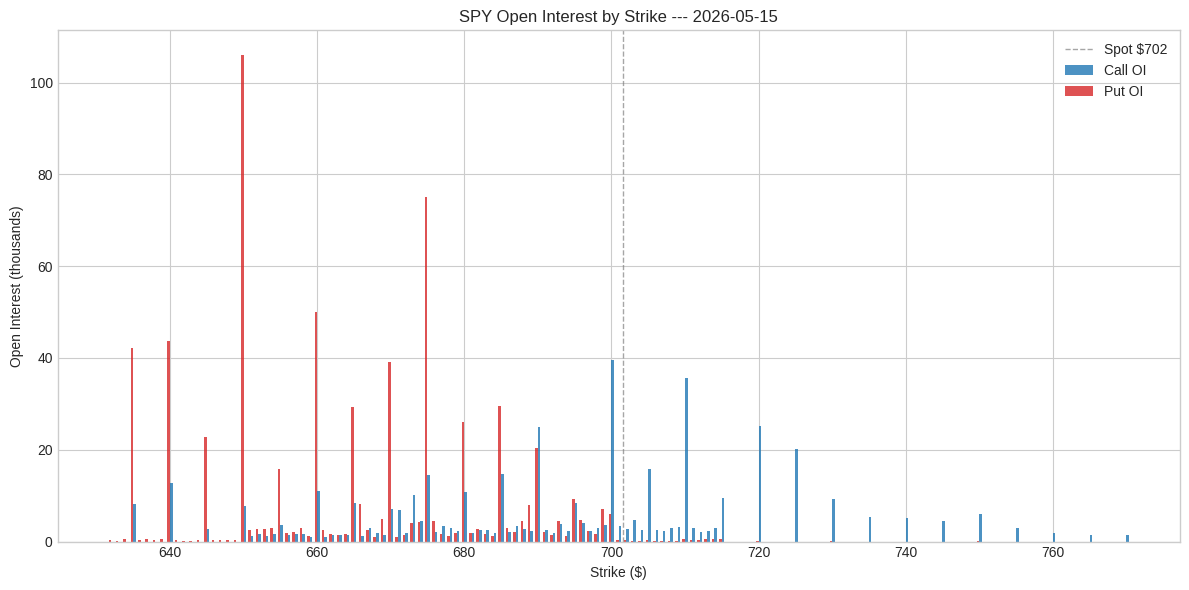

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

width = (chain["strike"].diff().median()) * 0.35 if len(chain) > 1 else 1
ax.bar(chain["strike"] - width / 2, chain["call_oi"] / 1000, width=width,
       color="#1f77b4", alpha=0.8, label="Call OI")
ax.bar(chain["strike"] + width / 2, chain["put_oi"] / 1000, width=width,
       color="#d62728", alpha=0.8, label="Put OI")

ax.axvline(x=spot_price, color="gray", linestyle="--", linewidth=1, alpha=0.7,
           label=f"Spot ${spot_price:.0f}")

ax.set_xlabel("Strike ($)")
ax.set_ylabel("Open Interest (thousands)")
ax.set_title(f"SPY Open Interest by Strike --- {monthly_exp}")
ax.legend()

plt.tight_layout()
plt.show()

---

**Next:** [104 --- Greeks and Volatility Surface](104_greeks_surface.ipynb)